# Web Mining YELP

In [ ]:
# =========================
# 1. Imports and setup
# =========================
import os
import re
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [ ]:
# =========================
# 2. Paths and configuration
# =========================
# Update these paths if your files are stored elsewhere.

DATA_DIR = Path("/content/data")

YELP_TRAIN_PATH = DATA_DIR / "train.csv"
YELP_TEST_PATH  = DATA_DIR / "test.csv"
AMAZON_TEST_PATH = DATA_DIR / "test_sub.csv"

TEXT_MAX_LEN = 200
MAX_VOCAB = 50_000
MIN_FREQ = 2
BATCH_SIZE = 256

TEXTCNN_CONFIG = {
    "emb_dim": 128,
    "num_filters": 128,
    "kernel_sizes": (3, 4, 5),
    "dropout": 0.5,
    "lr": 1e-3,
    "epochs": 10,
}

BILSTM_CONFIG = {
    "emb_dim": 128,
    "hidden_dim": 128,
    "dropout": 0.5,
    "lr": 1e-3,
    "epochs": 10,
}

BERT_MAX_LEN = 256
BERT_BATCH_SIZE_EVAL = 32

## Optional: mount Google Drive in Colab
Run the next cell only if your data is on Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%%bash
mkdir -p /content/data
unzip -q "/content/drive/MyDrive/Colab Notebooks/WebMining/amazon_reviews.zip" -d /content/data
unzip -q "/content/drive/MyDrive/Colab Notebooks/WebMining/yelp_reviews.zip" -d /content/data

In [ ]:
# =========================
# 3. Text preprocessing helpers
# =========================
URL_RE = re.compile(r"http\S+|www\.\S+")
HTML_RE = re.compile(r"<.*?>")
WS_RE = re.compile(r"\s+")

def preprocess_text(text: str) -> str:
    text = str(text).lower()
    text = URL_RE.sub(" ", text)
    text = HTML_RE.sub(" ", text)
    text = WS_RE.sub(" ", text).strip()
    return text

def simple_tokenize(text: str):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

def load_sentiment_csv(path: str | Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df.copy()
    df["label"] = df["label"].astype(int)
    df["text_clean"] = df["text"].map(preprocess_text)
    return df

def df_to_xy(df: pd.DataFrame):
    texts = df["text_clean"].astype(str).tolist()
    labels = df["label"].astype(int).values
    return texts, labels

In [ ]:
# =========================
# 4. Load datasets
# =========================
df_train_ylp = load_sentiment_csv(YELP_TRAIN_PATH)
df_test_ylp = load_sentiment_csv(YELP_TEST_PATH)
df_test_amz = load_sentiment_csv(AMAZON_TEST_PATH)

X_train_text, y_train = df_to_xy(df_train_ylp)
X_test_text, y_test = df_to_xy(df_test_ylp)
X_test_amz_text, y_test_amz = df_to_xy(df_test_amz)

print("Yelp train:", df_train_ylp.shape)
print("Yelp test :", df_test_ylp.shape)
print("Amazon test:", df_test_amz.shape)

display(df_train_ylp.head())

Yelp train: (560000, 3)
Yelp test : (38000, 3)
Amazon test: (38000, 4)


,text,label,text_clean
0,"Unfortunately, the frustration of being Dr. Go...",0,"unfortunately, the frustration of being dr. go..."
1,Been going to Dr. Goldberg for over 10 years. ...,1,been going to dr. goldberg for over 10 years. ...
2,I don't know what Dr. Goldberg was like before...,0,i don't know what dr. goldberg was like before...
3,I'm writing this review to give you a heads up...,0,i'm writing this review to give you a heads up...
4,All the food is great here. But the best thing...,1,all the food is great here. but the best thing...


## Shared vocabulary and classic DL datasets
The next section is used by **TextCNN** and **BiLSTM**.

In [ ]:
# =========================
# 5. Vocabulary and PyTorch datasets for TextCNN / BiLSTM
# =========================
def build_vocab(texts, max_vocab=50_000, min_freq=2, specials=("<pad>", "<unk>")):
    counter = Counter()
    for text in texts:
        counter.update(simple_tokenize(text))

    vocab = {token: idx for idx, token in enumerate(specials)}
    for word, freq in counter.most_common():
        if freq < min_freq:
            continue
        if word in vocab:
            continue
        vocab[word] = len(vocab)
        if len(vocab) >= max_vocab:
            break
    return vocab

def encode_text(text: str, vocab: dict, max_len: int):
    token_ids = [vocab.get(tok, vocab["<unk>"]) for tok in simple_tokenize(text)[:max_len]]
    if len(token_ids) < max_len:
        token_ids += [vocab["<pad>"]] * (max_len - len(token_ids))
    return token_ids

class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = torch.tensor(encode_text(self.texts[idx], self.vocab, self.max_len), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

def build_text_dataloader(texts, labels, vocab, max_len, batch_size, shuffle=False):
    ds = TextDataset(texts, labels, vocab, max_len)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0)

vocab = build_vocab(X_train_text, max_vocab=MAX_VOCAB, min_freq=MIN_FREQ)
PAD_IDX = vocab["<pad>"]

train_loader = build_text_dataloader(
    X_train_text, y_train, vocab, TEXT_MAX_LEN, BATCH_SIZE, shuffle=True
)
test_loader = build_text_dataloader(
    X_test_text, y_test, vocab, TEXT_MAX_LEN, BATCH_SIZE, shuffle=False
)
amazon_loader = build_text_dataloader(
    X_test_amz_text, y_test_amz, vocab, TEXT_MAX_LEN, BATCH_SIZE, shuffle=False
)

print("Vocab size:", len(vocab))

Vocab size: 50000


In [ ]:
# =========================
# 6. Shared training / evaluation utilities
# =========================
def binary_metrics_from_probs(y_true, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, preds),
        "macro_f1": f1_score(y_true, preds, average="macro"),
        "preds": preds,
    }

def run_binary_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    all_probs, all_y = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        if train_mode:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)
        probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
        labels = y.detach().cpu().numpy().astype(int).reshape(-1)

        all_probs.append(probs)
        all_y.append(labels)

    avg_loss = total_loss / len(loader.dataset)
    all_probs = np.concatenate(all_probs)
    all_y = np.concatenate(all_y)

    metrics = binary_metrics_from_probs(all_y, all_probs)
    metrics["loss"] = avg_loss
    metrics["labels"] = all_y
    metrics["probs"] = all_probs
    return metrics

def train_binary_model(model, train_loader, test_loader, epochs, lr, device=DEVICE):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "train_acc": [],
        "train_f1": [],
        "test_loss": [],
        "test_acc": [],
        "test_f1": [],
    }

    start = time.time()

    for epoch in range(1, epochs + 1):
        train_metrics = run_binary_epoch(model, train_loader, criterion, optimizer=optimizer, device=device)
        test_metrics = run_binary_epoch(model, test_loader, criterion, optimizer=None, device=device)

        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["accuracy"])
        history["train_f1"].append(train_metrics["macro_f1"])
        history["test_loss"].append(test_metrics["loss"])
        history["test_acc"].append(test_metrics["accuracy"])
        history["test_f1"].append(test_metrics["macro_f1"])

        print(
            f"Epoch {epoch:02d} | "
            f"train loss {train_metrics['loss']:.4f} acc {train_metrics['accuracy']:.4f} f1 {train_metrics['macro_f1']:.4f} | "
            f"test loss {test_metrics['loss']:.4f} acc {test_metrics['accuracy']:.4f} f1 {test_metrics['macro_f1']:.4f}"
        )

    elapsed = time.time() - start
    print(f"\nTotal training time: {elapsed:.2f}s")
    return model, history, elapsed

def evaluate_binary_model(model, loader, device=DEVICE, title=None):
    criterion = nn.BCEWithLogitsLoss()
    metrics = run_binary_epoch(model, loader, criterion, optimizer=None, device=device)

    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Macro F1: {metrics['macro_f1']:.4f}")
    print("\nClassification report:\n")
    print(classification_report(metrics["labels"], metrics["preds"], digits=4))

    if title is not None:
        plot_confusion_matrix(metrics["labels"], metrics["preds"], title=title)

    return metrics

def plot_history(history, model_name="Model"):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["test_loss"], label="Test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss Curves ({model_name})")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_acc"], label="Train accuracy")
    plt.plot(epochs, history["test_acc"], label="Test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy Curves ({model_name})")
    plt.legend()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", labels=("Negative", "Positive")):
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        values_format="d",
        display_labels=list(labels)
    )
    plt.title(title)
    plt.show()

def save_torch_checkpoint(path, model, history=None, extra=None):
    payload = {"model_state": model.state_dict()}
    if history is not None:
        payload["history"] = history
    if extra is not None:
        payload["extra"] = extra
    torch.save(payload, path)
    print(f"Saved to: {path}")

# TextCNN

In [ ]:
# =========================
# 7. TextCNN definition
# =========================
class TextCNN(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, num_filters=128, kernel_sizes=(3, 4, 5), dropout=0.5, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=emb_dim, out_channels=num_filters, kernel_size=k)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), 1)

    def forward(self, x):
        emb = self.embedding(x)
        emb = emb.transpose(1, 2)

        pooled_features = []
        for conv in self.convs:
            conv_out = torch.relu(conv(emb))
            pooled = torch.max(conv_out, dim=2).values
            pooled_features.append(pooled)

        features = torch.cat(pooled_features, dim=1)
        features = self.dropout(features)
        logits = self.fc(features).squeeze(1)
        return logits

In [ ]:
# =========================
# 8. Train TextCNN
# =========================
textcnn = TextCNN(
    vocab_size=len(vocab),
    emb_dim=TEXTCNN_CONFIG["emb_dim"],
    num_filters=TEXTCNN_CONFIG["num_filters"],
    kernel_sizes=TEXTCNN_CONFIG["kernel_sizes"],
    dropout=TEXTCNN_CONFIG["dropout"],
    pad_idx=PAD_IDX,
)

textcnn, textcnn_history, textcnn_train_time = train_binary_model(
    model=textcnn,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=TEXTCNN_CONFIG["epochs"],
    lr=TEXTCNN_CONFIG["lr"],
    device=DEVICE,
)

Epoch 01 | train loss 0.2668 acc 0.8845 f1 0.8845 | test loss 0.1690 acc 0.9350 f1 0.9350
Epoch 02 | train loss 0.1731 acc 0.9319 f1 0.9319 | test loss 0.1488 acc 0.9429 f1 0.9429
Epoch 03 | train loss 0.1489 acc 0.9426 f1 0.9426 | test loss 0.1457 acc 0.9449 f1 0.9449
Epoch 04 | train loss 0.1316 acc 0.9501 f1 0.9501 | test loss 0.1430 acc 0.9463 f1 0.9463
Epoch 05 | train loss 0.1188 acc 0.9556 f1 0.9556 | test loss 0.1440 acc 0.9467 f1 0.9467
Epoch 06 | train loss 0.1078 acc 0.9601 f1 0.9601 | test loss 0.1477 acc 0.9462 f1 0.9462
Epoch 07 | train loss 0.0977 acc 0.9639 f1 0.9639 | test loss 0.1550 acc 0.9463 f1 0.9463
Epoch 08 | train loss 0.0888 acc 0.9673 f1 0.9673 | test loss 0.1614 acc 0.9453 f1 0.9453
Epoch 09 | train loss 0.0815 acc 0.9702 f1 0.9702 | test loss 0.1699 acc 0.9455 f1 0.9455
Epoch 10 | train loss 0.0747 acc 0.9730 f1 0.9730 | test loss 0.1825 acc 0.9436 f1 0.9436

Total training time: 1381.56s


Accuracy: 0.9436
Macro F1: 0.9436

Classification report:

              precision    recall  f1-score   support

           0     0.9482    0.9385    0.9433     19000
           1     0.9391    0.9487    0.9439     19000

    accuracy                         0.9436     38000
   macro avg     0.9437    0.9436    0.9436     38000
weighted avg     0.9437    0.9436    0.9436     38000



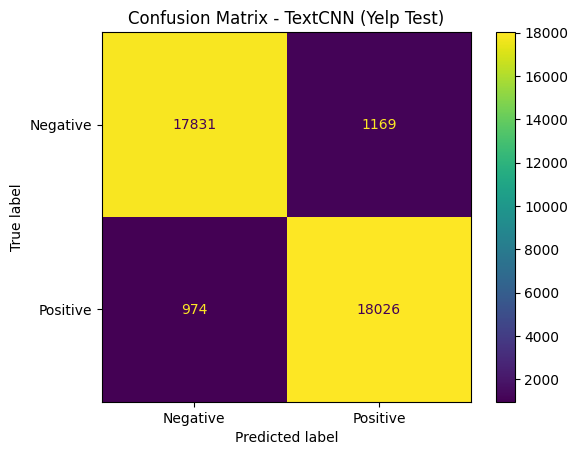

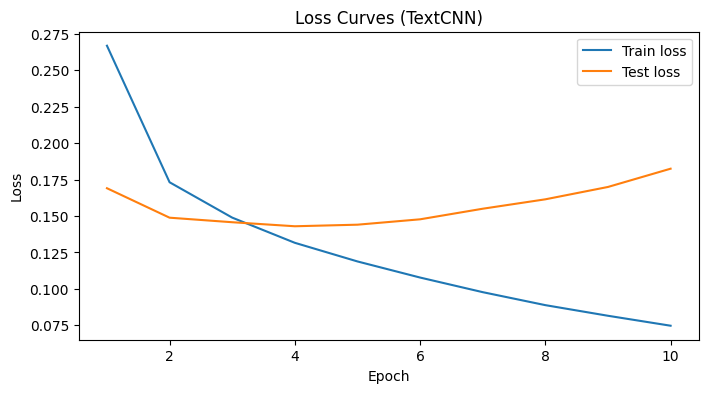

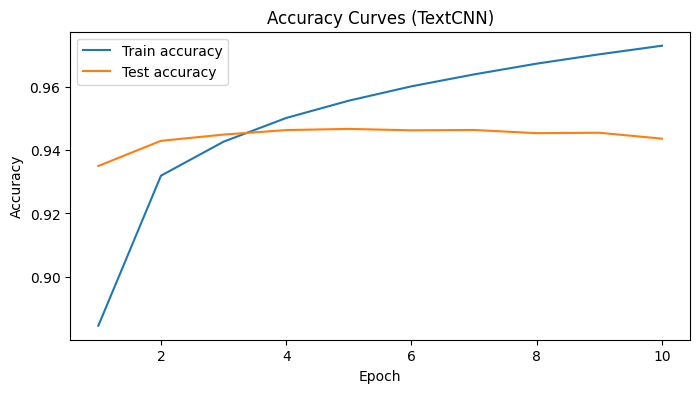

Saved to: textcnn_yelp.pt


In [ ]:
# Yelp test evaluation
textcnn_test_metrics = evaluate_binary_model(
    textcnn,
    test_loader,
    device=DEVICE,
    title="Confusion Matrix - TextCNN (Yelp Test)"
)

plot_history(textcnn_history, model_name="TextCNN")
save_torch_checkpoint("textcnn_yelp.pt", textcnn, history=textcnn_history)

# BiLSTM

In [ ]:
# =========================
# 9. BiLSTM definition
# =========================
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, pad_idx, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        emb = self.embedding(x)
        lstm_out, _ = self.lstm(emb)
        pooled = torch.max(lstm_out, dim=1).values
        pooled = self.dropout(pooled)
        logits = self.fc(pooled).squeeze(1)
        return logits

In [ ]:
# =========================
# 10. Train BiLSTM
# =========================
bilstm = BiLSTM(
    vocab_size=len(vocab),
    emb_dim=BILSTM_CONFIG["emb_dim"],
    hidden_dim=BILSTM_CONFIG["hidden_dim"],
    pad_idx=PAD_IDX,
    dropout=BILSTM_CONFIG["dropout"],
)

bilstm, bilstm_history, bilstm_train_time = train_binary_model(
    model=bilstm,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=BILSTM_CONFIG["epochs"],
    lr=BILSTM_CONFIG["lr"],
    device=DEVICE,
)

Epoch 01 | train loss 0.2328 acc 0.9018 f1 0.9018 | test loss 0.1486 acc 0.9425 f1 0.9425
Epoch 02 | train loss 0.1408 acc 0.9459 f1 0.9459 | test loss 0.1356 acc 0.9479 f1 0.9479
Epoch 03 | train loss 0.1174 acc 0.9556 f1 0.9556 | test loss 0.1240 acc 0.9533 f1 0.9533
Epoch 04 | train loss 0.1000 acc 0.9630 f1 0.9630 | test loss 0.1260 acc 0.9544 f1 0.9544
Epoch 05 | train loss 0.0854 acc 0.9690 f1 0.9690 | test loss 0.1315 acc 0.9538 f1 0.9538
Epoch 06 | train loss 0.0723 acc 0.9741 f1 0.9741 | test loss 0.1346 acc 0.9524 f1 0.9524
Epoch 07 | train loss 0.0643 acc 0.9768 f1 0.9768 | test loss 0.1487 acc 0.9531 f1 0.9531
Epoch 08 | train loss 0.0520 acc 0.9817 f1 0.9817 | test loss 0.1593 acc 0.9518 f1 0.9518
Epoch 09 | train loss 0.0455 acc 0.9841 f1 0.9841 | test loss 0.1673 acc 0.9522 f1 0.9522
Epoch 10 | train loss 0.0366 acc 0.9875 f1 0.9875 | test loss 0.1807 acc 0.9495 f1 0.9495

Total training time: 1720.19s


Accuracy: 0.9495
Macro F1: 0.9495

Classification report:

              precision    recall  f1-score   support

           0     0.9557    0.9428    0.9492     19000
           1     0.9436    0.9563    0.9499     19000

    accuracy                         0.9495     38000
   macro avg     0.9496    0.9495    0.9495     38000
weighted avg     0.9496    0.9495    0.9495     38000



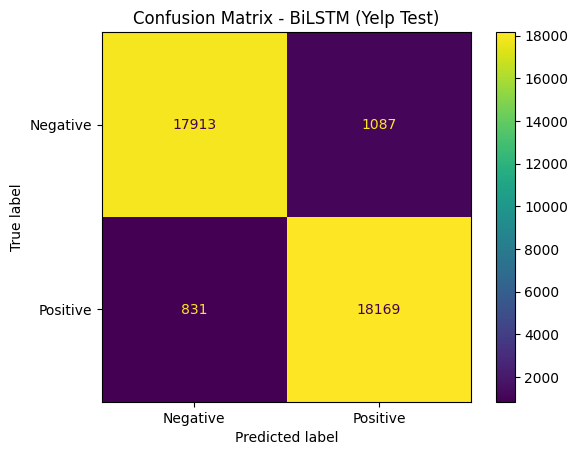

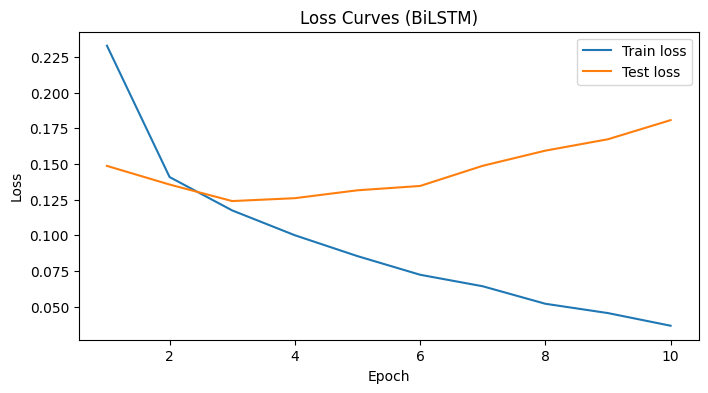

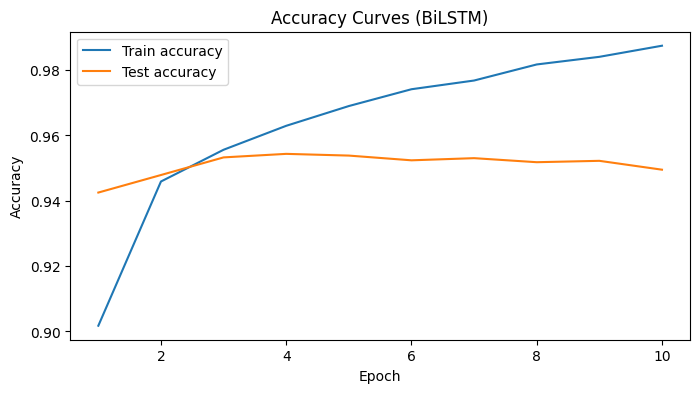

Saved to: bilstm_yelp.pt


In [ ]:
# Yelp test evaluation
bilstm_test_metrics = evaluate_binary_model(
    bilstm,
    test_loader,
    device=DEVICE,
    title="Confusion Matrix - BiLSTM (Yelp Test)"
)

plot_history(bilstm_history, model_name="BiLSTM")
save_torch_checkpoint("bilstm_yelp.pt", bilstm, history=bilstm_history)

# Transformer-based models (BERT / DistilBERT)

In [ ]:
# =========================
# 11. Install / import transformers
# =========================
# Uncomment in a fresh Colab runtime:
!pip -q install transformers datasets accelerate scikit-learn

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)

In [ ]:
# =========================
# 12. Hugging Face dataset helpers
# =========================
class SentimentDatasetHF(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item

def build_hf_dataset(df, tokenizer, max_len=BERT_MAX_LEN):
    return SentimentDatasetHF(
        texts=df["text_clean"].tolist(),
        labels=df["label"].tolist(),
        tokenizer=tokenizer,
        max_len=max_len
    )

def compute_hf_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

def evaluate_hf_model_manual(model, dataset, batch_size=32, device=DEVICE, title=None):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].cpu().numpy()

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print("\nClassification report:\n")
    print(classification_report(all_labels, all_preds, digits=4))

    if title is not None:
        plot_confusion_matrix(all_labels, all_preds, title=title, labels=("negative", "positive"))

    return {
        "labels": all_labels,
        "preds": all_preds,
        "accuracy": acc,
        "macro_f1": macro_f1,
    }

## Pretrained BERT without fine-tuning

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Accuracy: 0.9150
Macro F1: 0.9150

Classification report:

              precision    recall  f1-score   support

           0     0.9030    0.9298    0.9162     19000
           1     0.9277    0.9002    0.9137     19000

    accuracy                         0.9150     38000
   macro avg     0.9154    0.9150    0.9150     38000
weighted avg     0.9154    0.9150    0.9150     38000



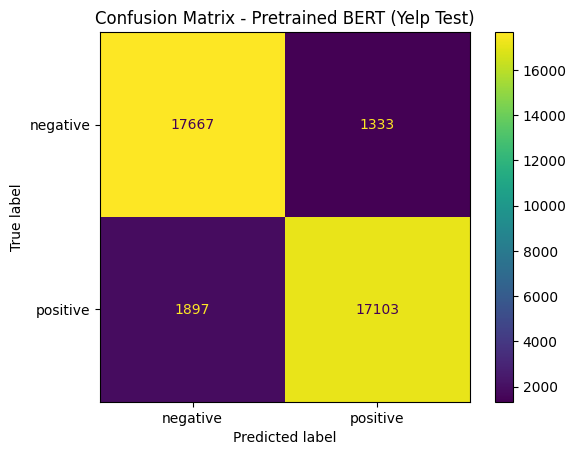

In [ ]:
# =========================
# 13. Evaluate pretrained BERT on Yelp test
# =========================
raw_model_name = "textattack/bert-base-uncased-SST-2"

raw_tokenizer = AutoTokenizer.from_pretrained(raw_model_name)
raw_model = AutoModelForSequenceClassification.from_pretrained(raw_model_name).to(DEVICE)

raw_yelp_test_dataset = build_hf_dataset(df_test_ylp, raw_tokenizer, max_len=BERT_MAX_LEN)

raw_yelp_metrics = evaluate_hf_model_manual(
    raw_model,
    raw_yelp_test_dataset,
    batch_size=BERT_BATCH_SIZE_EVAL,
    device=DEVICE,
    title="Confusion Matrix - Pretrained BERT (Yelp Test)"
)

## Fine-tuned DistilBERT on Yelp

In [ ]:
# =========================
# 14. Fine-tune DistilBERT
# =========================
ft_model_name = "distilbert-base-uncased"

ft_tokenizer = AutoTokenizer.from_pretrained(ft_model_name)
ft_model = AutoModelForSequenceClassification.from_pretrained(ft_model_name, num_labels=2).to(DEVICE)

train_dataset_hf = build_hf_dataset(df_train_ylp, ft_tokenizer, max_len=BERT_MAX_LEN)
test_dataset_hf = build_hf_dataset(df_test_ylp, ft_tokenizer, max_len=BERT_MAX_LEN)

training_args = TrainingArguments(
    output_dir="./bert_sentiment_results",
    eval_strategy="epoch",
    save_strategy="no",
    logging_strategy="steps",
    logging_steps=1000,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    learning_rate=2e-5,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=train_dataset_hf,
    eval_dataset=test_dataset_hf,
    compute_metrics=compute_hf_metrics,
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.092720,0.081849,0.969763,0.969763
2,0.062963,0.081025,0.971789,0.971789


TrainOutput(global_step=17500, training_loss=0.08893402502877372, metrics={'train_runtime': 7048.7664, 'train_samples_per_second': 158.893, 'train_steps_per_second': 2.483, 'total_flos': 7.418174324736e+16, 'train_loss': 0.08893402502877372, 'epoch': 2.0})

Trainer evaluate: {'eval_loss': 0.08102454245090485, 'eval_accuracy': 0.9717894736842105, 'eval_macro_f1': 0.9717894736842105, 'eval_runtime': 92.4608, 'eval_samples_per_second': 410.985, 'eval_steps_per_second': 12.849, 'epoch': 2.0}

Classification report:

              precision    recall  f1-score   support

           0     0.9718    0.9718    0.9718     19000
           1     0.9718    0.9718    0.9718     19000

    accuracy                         0.9718     38000
   macro avg     0.9718    0.9718    0.9718     38000
weighted avg     0.9718    0.9718    0.9718     38000



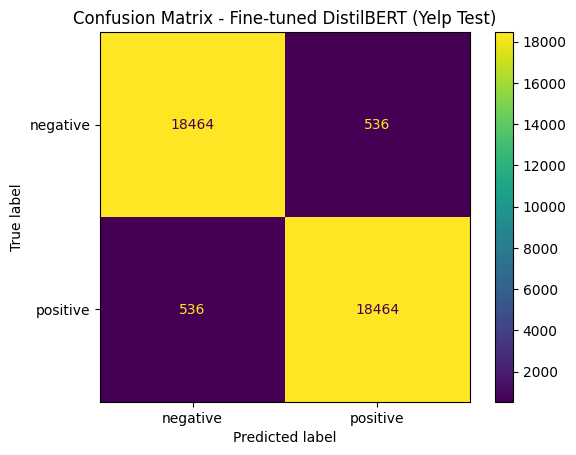

In [ ]:
# Yelp test evaluation for fine-tuned DistilBERT
ft_eval_results = trainer.evaluate()
print("Trainer evaluate:", ft_eval_results)

pred_output = trainer.predict(test_dataset_hf)
ft_logits = pred_output.predictions
ft_labels = pred_output.label_ids
ft_preds = np.argmax(ft_logits, axis=1)

print("\nClassification report:\n")
print(classification_report(ft_labels, ft_preds, digits=4))
plot_confusion_matrix(ft_labels, ft_preds, title="Confusion Matrix - Fine-tuned DistilBERT (Yelp Test)", labels=("negative", "positive"))

In [ ]:
# Save fine-tuned model
FT_SAVE_PATH = "./bert_finetuned"
trainer.save_model(FT_SAVE_PATH)
ft_tokenizer.save_pretrained(FT_SAVE_PATH)
print("Saved fine-tuned model to:", FT_SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved fine-tuned model to: ./bert_finetuned


In [ ]:
import shutil
from google.colab import files

shutil.make_archive("bert_finetuned", "zip", "./bert_finetuned")
files.download("./bert_finetuned.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
shutil.make_archive("bert_sentiment_results", "zip", "./bert_sentiment_results")
files.download("./bert_sentiment_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Cross-domain evaluation: Yelp → Amazon

=== TextCNN: Yelp -> Amazon ===
Accuracy: 0.8446
Macro F1: 0.8397

Classification report:

              precision    recall  f1-score   support

           0     0.7880    0.8366    0.8116     15200
           1     0.8864    0.8500    0.8678     22800

    accuracy                         0.8446     38000
   macro avg     0.8372    0.8433    0.8397     38000
weighted avg     0.8471    0.8446    0.8453     38000



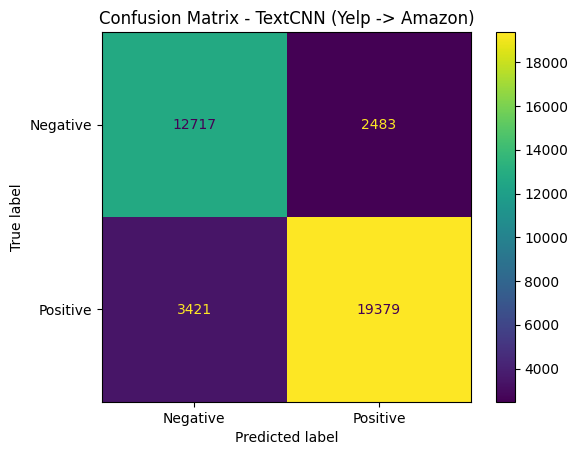


=== BiLSTM: Yelp -> Amazon ===
Accuracy: 0.8557
Macro F1: 0.8507

Classification report:

              precision    recall  f1-score   support

           0     0.8067    0.8407    0.8234     15200
           1     0.8907    0.8657    0.8780     22800

    accuracy                         0.8557     38000
   macro avg     0.8487    0.8532    0.8507     38000
weighted avg     0.8571    0.8557    0.8562     38000



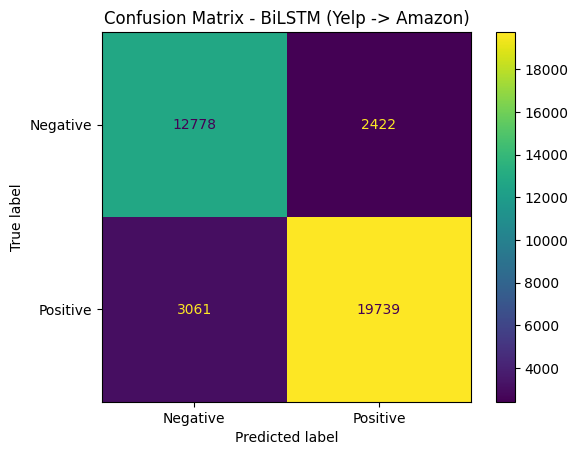

In [ ]:
# =========================
# 15. Cross-domain evaluation for TextCNN and BiLSTM
# =========================
print("=== TextCNN: Yelp -> Amazon ===")
textcnn_amz_metrics = evaluate_binary_model(
    textcnn,
    amazon_loader,
    device=DEVICE,
    title="Confusion Matrix - TextCNN (Yelp -> Amazon)"
)

print("\n=== BiLSTM: Yelp -> Amazon ===")
bilstm_amz_metrics = evaluate_binary_model(
    bilstm,
    amazon_loader,
    device=DEVICE,
    title="Confusion Matrix - BiLSTM (Yelp -> Amazon)"
)

=== Fine-tuned DistilBERT: Yelp -> Amazon ===
Accuracy: 0.9292631578947368
Macro F1: 0.9265879645527388

Classification report:

              precision    recall  f1-score   support

           0     0.9024    0.9230    0.9126     15200
           1     0.9478    0.9335    0.9406     22800

    accuracy                         0.9293     38000
   macro avg     0.9251    0.9282    0.9266     38000
weighted avg     0.9297    0.9293    0.9294     38000



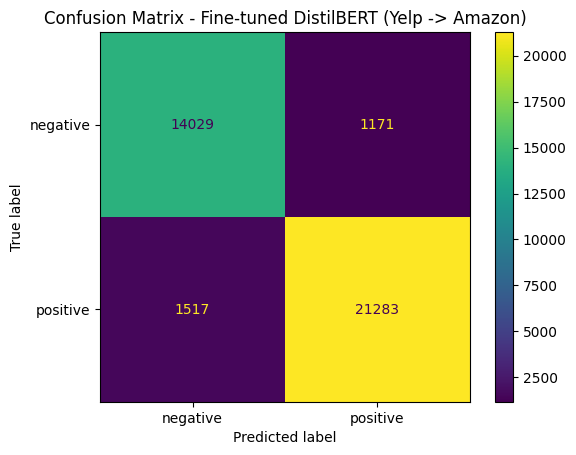

In [ ]:
# =========================
# 16. Cross-domain evaluation for fine-tuned DistilBERT
# =========================
amazon_dataset_hf = build_hf_dataset(df_test_amz, ft_tokenizer, max_len=BERT_MAX_LEN)

amz_pred_output = trainer.predict(amazon_dataset_hf)
amz_logits = amz_pred_output.predictions
amz_labels = amz_pred_output.label_ids
amz_preds = np.argmax(amz_logits, axis=1)

print("=== Fine-tuned DistilBERT: Yelp -> Amazon ===")
print("Accuracy:", accuracy_score(amz_labels, amz_preds))
print("Macro F1:", f1_score(amz_labels, amz_preds, average="macro"))
print("\nClassification report:\n")
print(classification_report(amz_labels, amz_preds, digits=4))

plot_confusion_matrix(amz_labels, amz_preds, title="Confusion Matrix - Fine-tuned DistilBERT (Yelp -> Amazon)", labels=("negative", "positive"))

# Optional summary table
Use this section after all models finish running.

In [ ]:
# =========================
# 17. Collect results in one table
# =========================
summary_rows = [
    {
        "model": "TextCNN",
        "domain": "Yelp test",
        "accuracy": textcnn_test_metrics["accuracy"],
        "macro_f1": textcnn_test_metrics["macro_f1"],
    },
    {
        "model": "BiLSTM",
        "domain": "Yelp test",
        "accuracy": bilstm_test_metrics["accuracy"],
        "macro_f1": bilstm_test_metrics["macro_f1"],
    },
    {
        "model": "Pretrained BERT",
        "domain": "Yelp test",
        "accuracy": raw_yelp_metrics["accuracy"],
        "macro_f1": raw_yelp_metrics["macro_f1"],
    },
    {
        "model": "Fine-tuned DistilBERT",
        "domain": "Yelp test",
        "accuracy": accuracy_score(ft_labels, ft_preds),
        "macro_f1": f1_score(ft_labels, ft_preds, average="macro"),
    },
    {
        "model": "TextCNN",
        "domain": "Yelp -> Amazon",
        "accuracy": textcnn_amz_metrics["accuracy"],
        "macro_f1": textcnn_amz_metrics["macro_f1"],
    },
    {
        "model": "BiLSTM",
        "domain": "Yelp -> Amazon",
        "accuracy": bilstm_amz_metrics["accuracy"],
        "macro_f1": bilstm_amz_metrics["macro_f1"],
    },
    {
        "model": "Fine-tuned DistilBERT",
        "domain": "Yelp -> Amazon",
        "accuracy": accuracy_score(amz_labels, amz_preds),
        "macro_f1": f1_score(amz_labels, amz_preds, average="macro"),
    },
]

results_df = pd.DataFrame(summary_rows)
display(results_df.sort_values(["domain", "macro_f1"], ascending=[True, False]).reset_index(drop=True))

,model,domain,accuracy,macro_f1
0,Fine-tuned DistilBERT,Yelp -> Amazon,0.929263,0.926588
1,BiLSTM,Yelp -> Amazon,0.855711,0.850701
2,TextCNN,Yelp -> Amazon,0.844632,0.839705
3,Fine-tuned DistilBERT,Yelp test,0.971789,0.971789
4,BiLSTM,Yelp test,0.949526,0.949524
5,TextCNN,Yelp test,0.943605,0.943604
6,Pretrained BERT,Yelp test,0.915000,0.914981
